# FoodSure AI — Model Explainability

## Understanding Features Behind Turmeric Adulteration Predictions

This notebook investigates which input features contribute most strongly to
turmeric adulteration classification and quantification.

Explainability is important because high predictive performance alone does not
show which characteristics of the data are being used by a model.

The analysis focuses on:

1. FTIR spectral feature importance
2. Color feature importance
3. EfficientNet-B0 feature importance
4. Model-based feature importance
5. Permutation importance
6. Interpretation of important spectral regions

### Research Questions

- Which FTIR regions contribute most to prediction?
- Which color measurements are informative?
- Which image-derived features contribute to prediction?
- Are important features consistent across models?
- Can model importance provide useful scientific insight?

### Important Note

Feature importance indicates statistical contribution to model predictions.
It does not by itself establish chemical causation.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nSearching for X_color_train_scaled.csv...")

for root, dirs, files in os.walk(".."):
    if "X_color_train_scaled.csv" in files:
        print("FOUND:")
        print(os.path.join(root, "X_color_train_scaled.csv"))
        break

Current working directory:
c:\Users\Dell\Downloads\Multimodal Dataset for Turmeric Adulteration Detec\notebook

Searching for X_color_train_scaled.csv...
FOUND:
..\preprocessed\X_color_train_scaled.csv


In [ ]:
preprocessed_dir = "../preprocessed"

X_color_train_scaled = pd.read_csv(
    os.path.join(preprocessed_dir, "X_color_train_scaled.csv")
).values

X_color_test_scaled = pd.read_csv(
    os.path.join(preprocessed_dir, "X_color_test_scaled.csv")
).values

X_ftir_train_scaled = pd.read_csv(
    os.path.join(preprocessed_dir, "X_ftir_train_scaled.csv")
).values

X_ftir_test_scaled = pd.read_csv(
    os.path.join(preprocessed_dir, "X_ftir_test_scaled.csv")
).values

X_image_train_scaled = pd.read_csv(
    os.path.join(preprocessed_dir, "X_image_train_scaled.csv")
).values

X_image_test_scaled = pd.read_csv(
    os.path.join(preprocessed_dir, "X_image_test_scaled.csv")
).values

y_train = pd.read_csv(
    os.path.join(preprocessed_dir, "y_train.csv")
).squeeze()

y_test = pd.read_csv(
    os.path.join(preprocessed_dir, "y_test.csv")
).squeeze()

print("Color:", X_color_train_scaled.shape)
print("FTIR:", X_ftir_train_scaled.shape)
print("Image:", X_image_train_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Color: (280, 46)
FTIR: (280, 2522)
Image: (280, 1280)
y_train: (280,)
y_test: (70,)


## 4. FTIR Wavenumber Mapping

The original FTIR dataset contains spectral measurements indexed by wavenumber.

The feature names are recovered from the original dataset so that model-derived
importance values can be mapped back to physical spectral positions.

In [ ]:
ftir_path = "../dataset/FTIR Spectroscopy/FTIR_Data.csv"

ftir_raw = pd.read_csv(ftir_path)

ftir_feature_names = [
    col for col in ftir_raw.columns
    if col not in ["Sample ID", "Target", "Unnamed: 2524"]
]

wavenumbers = np.array(
    [float(col) for col in ftir_feature_names]
)

print("Number of FTIR features:", len(ftir_feature_names))
print(
    "Wavenumber range:",
    wavenumbers.min(),
    "to",
    wavenumbers.max(),
    "cm⁻¹"
)

Number of FTIR features: 2522
Wavenumber range: 399.47297 to 3996.15644 cm⁻¹


FTIR Random Forest Explainability :- 

## 5. FTIR Feature Importance

A Random Forest classifier is trained using the original scaled FTIR features.

The model's feature importance values are used to identify FTIR variables that
contribute most strongly to classification among the seven adulteration levels.

The important features are mapped back to their corresponding FTIR wavenumbers.

In [ ]:
ftir_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

ftir_rf.fit(
    X_ftir_train_scaled,
    y_train
)

y_ftir_rf_pred = ftir_rf.predict(
    X_ftir_test_scaled
)

print(
    "FTIR Random Forest Accuracy:",
    accuracy_score(y_test, y_ftir_rf_pred)
)

print(
    "FTIR Random Forest Macro F1:",
    f1_score(
        y_test,
        y_ftir_rf_pred,
        average="macro"
    )
)

FTIR Random Forest Accuracy: 1.0
FTIR Random Forest Macro F1: 1.0


Extract Feature Importance

In [ ]:
ftir_importance = pd.DataFrame({
    "Wavenumber_cm-1": wavenumbers,
    "Importance": ftir_rf.feature_importances_
})

ftir_importance = ftir_importance.sort_values(
    "Importance",
    ascending=False
)

ftir_importance.head(20)

,Wavenumber_cm-1,Importance
15,420.87331,0.009889
204,690.51757,0.007845
203,689.09088,0.007840
2515,3987.59630,0.007518
185,663.41048,0.006628
158,624.88987,0.006532
1,400.89966,0.006203
49,469.38075,0.005902
184,661.98379,0.005870
2447,3890.58143,0.005721


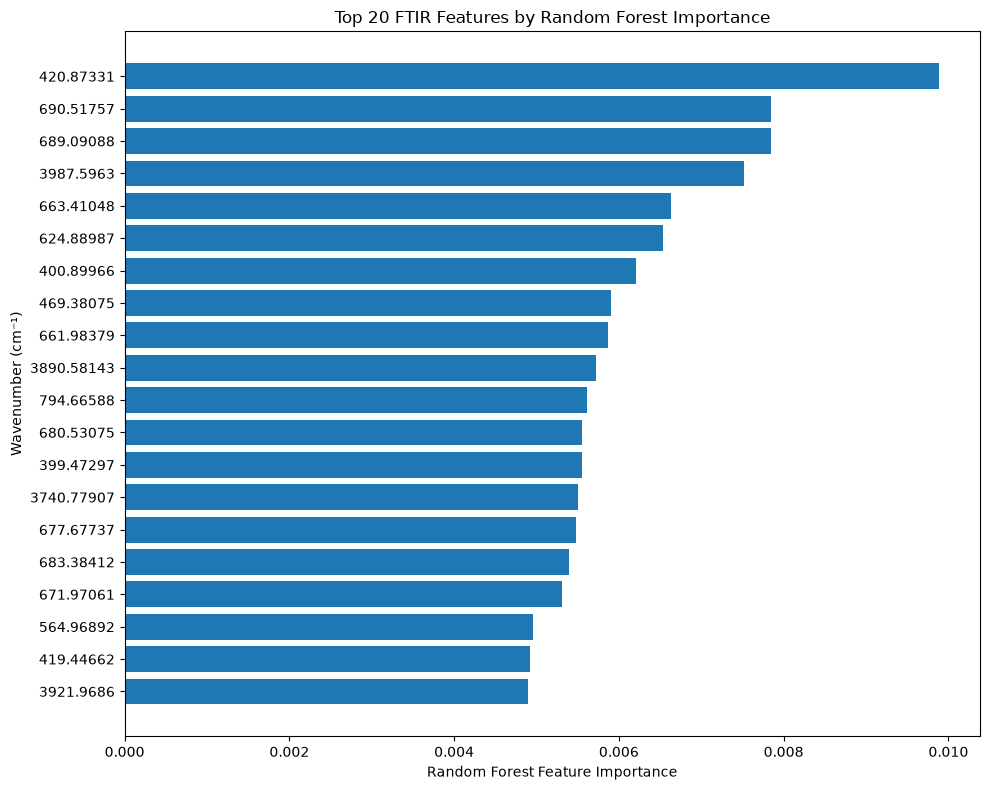

In [ ]:
top_ftir = ftir_importance.head(20).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_ftir["Wavenumber_cm-1"].astype(str),
    top_ftir["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Wavenumber (cm⁻¹)")
plt.title("Top 20 FTIR Features by Random Forest Importance")

plt.tight_layout()
plt.show()

## 8. FTIR Spectral Region Importance

Individual FTIR wavelengths can be highly correlated with neighboring wavelengths.

Therefore, feature importance is also examined across broader spectral regions.

This helps determine whether important model features form consistent spectral
clusters rather than appearing only as isolated wavelengths.

The analysis uses four broad regions:

- 400–800 cm⁻¹
- 800–1800 cm⁻¹
- 1800–2800 cm⁻¹
- 2800–4000 cm⁻¹

These regions are used for model-analysis purposes and should not be interpreted
as definitive chemical assignments.

In [ ]:
def assign_spectral_region(wavenumber):
    if 399 <= wavenumber < 800:
        return "399–800 cm⁻¹"
    elif 800 <= wavenumber < 1800:
        return "800–1800 cm⁻¹"
    elif 1800 <= wavenumber < 2800:
        return "1800–2800 cm⁻¹"
    elif 2800 <= wavenumber <= 4000:
        return "2800–4000 cm⁻¹"
    else:
        return "Outside range"


ftir_importance["Region"] = (
    ftir_importance["Wavenumber_cm-1"]
    .apply(assign_spectral_region)
)

region_importance = (
    ftir_importance
    .groupby("Region")["Importance"]
    .agg(
        Total_Importance="sum",
        Mean_Importance="mean",
        Maximum_Importance="max",
        Number_of_Features="count"
    )
    .reset_index()
)

region_importance["Relative_Importance"] = (
    region_importance["Total_Importance"]
    / region_importance["Total_Importance"].sum()
)

region_importance.sort_values(
    "Relative_Importance",
    ascending=False
)

,Region,Total_Importance,Mean_Importance,Maximum_Importance,Number_of_Features,Relative_Importance
2,399–800 cm⁻¹,0.466503,0.001660,0.009889,281,0.466503
1,2800–4000 cm⁻¹,0.370717,0.000442,0.007518,839,0.370717
3,800–1800 cm⁻¹,0.092048,0.000131,0.004847,701,0.092048
0,1800–2800 cm⁻¹,0.070732,0.000101,0.003847,701,0.070732


In [ ]:
region_importance["Relative_Importance"] = (
    region_importance["Total_Importance"]
    / region_importance["Total_Importance"].sum()
)

region_importance.sort_values(
    "Relative_Importance",
    ascending=False
)

,Region,Total_Importance,Mean_Importance,Maximum_Importance,Number_of_Features,Relative_Importance
2,399–800 cm⁻¹,0.466503,0.001660,0.009889,281,0.466503
1,2800–4000 cm⁻¹,0.370717,0.000442,0.007518,839,0.370717
3,800–1800 cm⁻¹,0.092048,0.000131,0.004847,701,0.092048
0,1800–2800 cm⁻¹,0.070732,0.000101,0.003847,701,0.070732


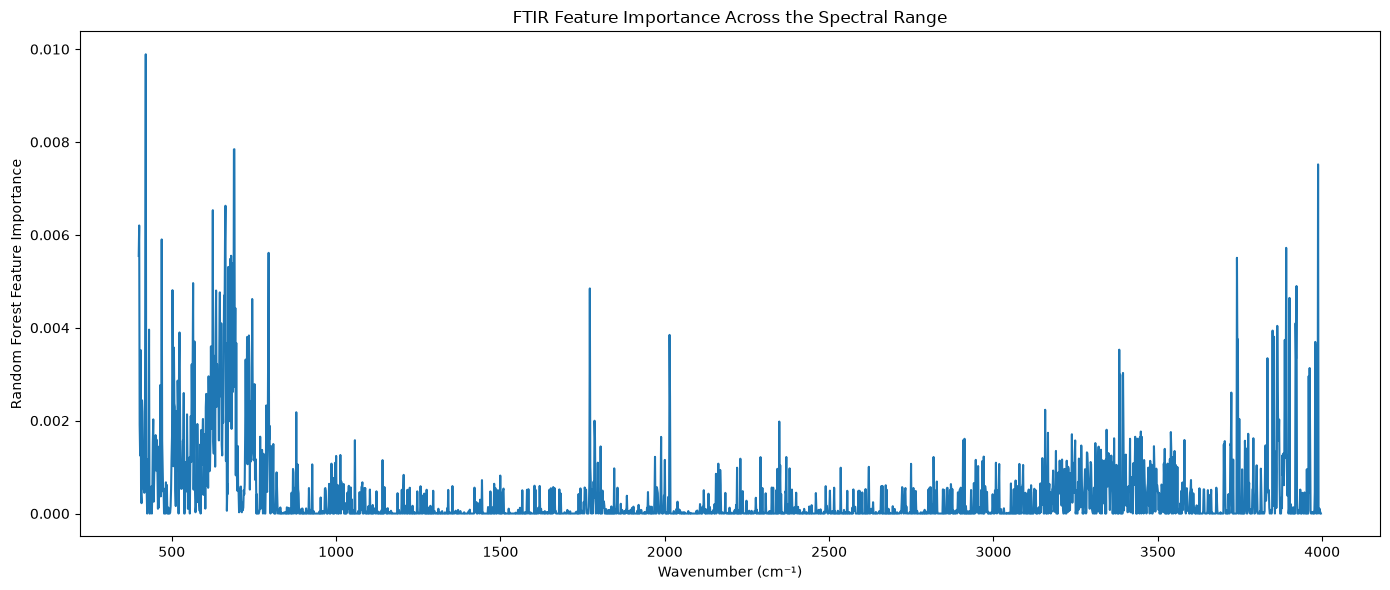

In [ ]:
importance_by_wavenumber = ftir_importance.sort_values(
    "Wavenumber_cm-1"
)

plt.figure(figsize=(14, 6))

plt.plot(
    importance_by_wavenumber["Wavenumber_cm-1"],
    importance_by_wavenumber["Importance"]
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Random Forest Feature Importance")
plt.title("FTIR Feature Importance Across the Spectral Range")

plt.tight_layout()
plt.show()

400–800        → many strong peaks
800–1800       → mostly lower importance
1800–2800      → relatively sparse
2800–4000      → increasing importance + strong peaks near upper end

## 9. FTIR Permutation Importance

Permutation importance provides a model-agnostic measure of feature contribution.

For each feature, its values are randomly shuffled while the remaining features
are kept unchanged. The resulting decrease in model performance indicates how
much the feature contributes to the model's predictive performance.

Permutation importance is used as a complementary analysis to Random Forest
impurity-based feature importance.

Because the FTIR dataset contains 2522 spectral variables, the analysis is
performed using a limited number of repetitions to control computational cost.

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    ftir_rf,
    X_ftir_test_scaled,
    y_test,
    scoring="f1_macro",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance completed.")
print("Number of features:", len(perm_result.importances_mean))

Permutation importance completed.
Number of features: 2522


In [ ]:
ftir_permutation = pd.DataFrame({
    "Wavenumber_cm-1": wavenumbers,
    "Permutation_Importance": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

ftir_permutation = ftir_permutation.sort_values(
    "Permutation_Importance",
    ascending=False
)

ftir_permutation.head(20)

,Wavenumber_cm-1,Permutation_Importance,Importance_STD
0,399.47297,0.0,0.0
1,400.89966,0.0,0.0
2,402.32635,0.0,0.0
3,403.75304,0.0,0.0
4,405.17973,0.0,0.0
5,406.60642,0.0,0.0
6,408.03311,0.0,0.0
7,409.45980,0.0,0.0
8,410.88649,0.0,0.0
9,412.31318,0.0,0.0


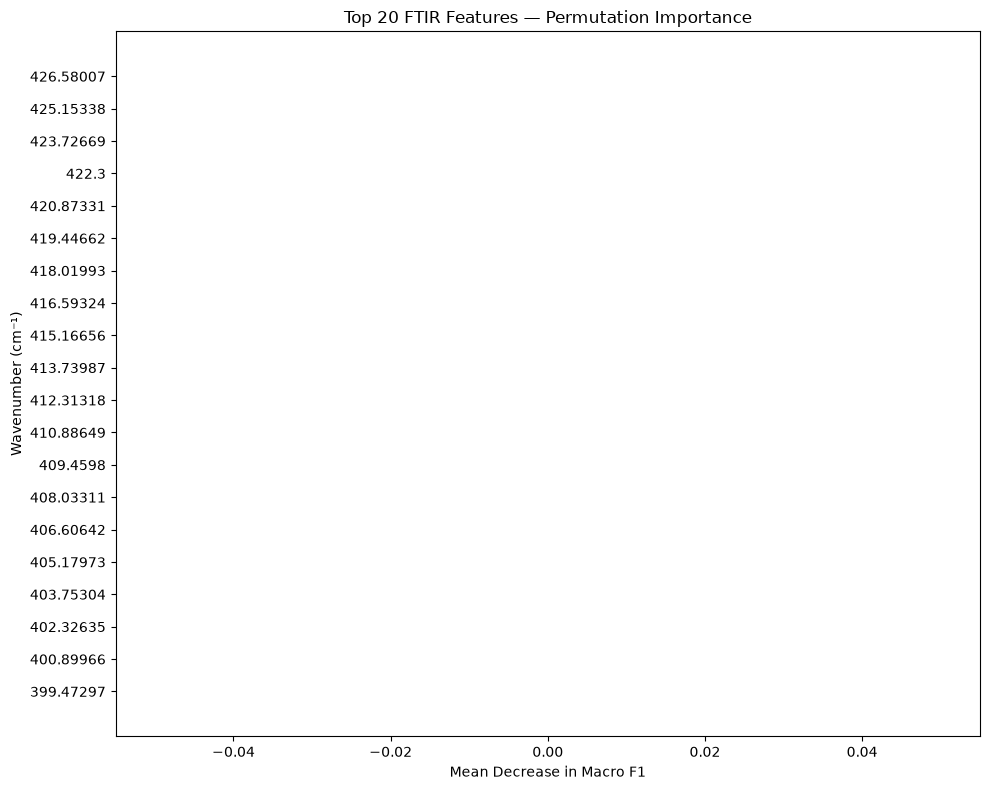

In [ ]:
top_perm = (
    ftir_permutation
    .head(20)
    .sort_values("Permutation_Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_perm["Wavenumber_cm-1"].astype(str),
    top_perm["Permutation_Importance"]
)

plt.xlabel("Mean Decrease in Macro F1")
plt.ylabel("Wavenumber (cm⁻¹)")
plt.title("Top 20 FTIR Features — Permutation Importance")

plt.tight_layout()
plt.show()

## 10. Color Feature Importance

Random Forest feature importance is used to identify which color measurements
contribute most strongly to adulteration classification.

The analysis includes both Hunter Lab measurements and wavelength-based color
measurements.

Feature importance represents statistical contribution to model predictions and
does not establish chemical causation.

In [ ]:
color_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

color_rf.fit(
    X_color_train_scaled,
    y_train
)

y_color_rf_pred = color_rf.predict(
    X_color_test_scaled
)

print(
    "Color Random Forest Accuracy:",
    accuracy_score(y_test, y_color_rf_pred)
)

print(
    "Color Random Forest Macro F1:",
    f1_score(
        y_test,
        y_color_rf_pred,
        average="macro"
    )
)

Color Random Forest Accuracy: 0.9142857142857143
Color Random Forest Macro F1: 0.9141424991049052


10.1 Get the actual Color feature names

In [ ]:
color_path = "../dataset/Color Measurement/Hunter_Lab_colorimeter.csv"

color_raw = pd.read_csv(color_path)

color_feature_names = [
    col for col in color_raw.columns
    if col not in [
        "Sample_ID",
        "Target",
        "Adulteration_Percent"
    ]
]

print("Number of Color features:", len(color_feature_names))
print(color_feature_names)

Number of Color features: 46
['L*', 'a*', 'b*', '360', '370', '380', '390', '400', '410', '420', '430', '440', '450', '460', '470', '480', '490', '500', '510', '520', '530', '540', '550', '560', '570', '580', '590', '600', '610', '620', '630', '640', '650', '660', '670', '680', '690', '700', '710', '720', '730', '740', '750', '760', '770', '780']


In [ ]:
color_importance = pd.DataFrame({
    "Feature": color_feature_names,
    "Importance": color_rf.feature_importances_
})

color_importance = color_importance.sort_values(
    "Importance",
    ascending=False
)

color_importance.head(20)

,Feature,Importance
18,510,0.064205
17,500,0.062394
1,a*,0.058449
16,490,0.051807
19,520,0.051289
5,380,0.039141
20,530,0.032279
2,b*,0.030921
40,730,0.027824
0,L*,0.025473


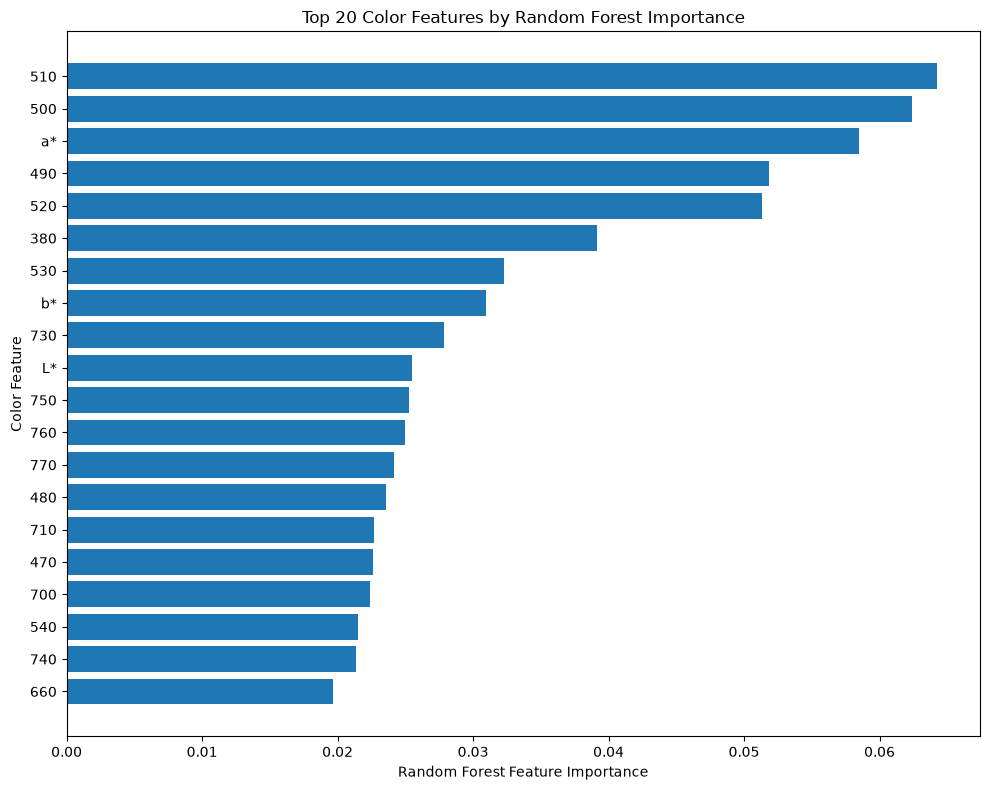

In [ ]:
top_color = (
    color_importance
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_color["Feature"],
    top_color["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Color Feature")
plt.title("Top 20 Color Features by Random Forest Importance")

plt.tight_layout()
plt.show()

## 10. Color Feature Importance

Random Forest feature importance is used to identify which color measurements
contribute most strongly to adulteration classification.

The analysis includes Hunter Lab measurements and wavelength-based color
measurements.

Feature importance represents statistical contribution to model predictions.
It does not establish chemical causation.

In [ ]:
color_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

color_rf.fit(
    X_color_train_scaled,
    y_train
)

y_color_rf_pred = color_rf.predict(
    X_color_test_scaled
)

print(
    "Color Random Forest Accuracy:",
    accuracy_score(y_test, y_color_rf_pred)
)

print(
    "Color Random Forest Macro F1:",
    f1_score(
        y_test,
        y_color_rf_pred,
        average="macro"
    )
)

Color Random Forest Accuracy: 0.9142857142857143
Color Random Forest Macro F1: 0.9141424991049052


### 10.4 Lab and Wavelength Feature Importance

The color features are separated into Hunter Lab measurements and wavelength
measurements.

This provides a higher-level view of whether model importance is concentrated
in the three-dimensional Lab representation or in the wavelength-based color
measurements.

In [ ]:
lab_features = ["L*", "a*", "b*"]

color_importance["Feature_Type"] = np.where(
    color_importance["Feature"].isin(lab_features),
    "Hunter Lab",
    "Wavelength"
)

color_group_importance = (
    color_importance
    .groupby("Feature_Type")["Importance"]
    .agg(
        Total_Importance="sum",
        Mean_Importance="mean",
        Maximum_Importance="max",
        Number_of_Features="count"
    )
    .reset_index()
)

color_group_importance["Relative_Importance"] = (
    color_group_importance["Total_Importance"]
    / color_group_importance["Total_Importance"].sum()
)

color_group_importance

,Feature_Type,Total_Importance,Mean_Importance,Maximum_Importance,Number_of_Features,Relative_Importance
0,Hunter Lab,0.114843,0.038281,0.058449,3,0.114843
1,Wavelength,0.885157,0.020585,0.064205,43,0.885157


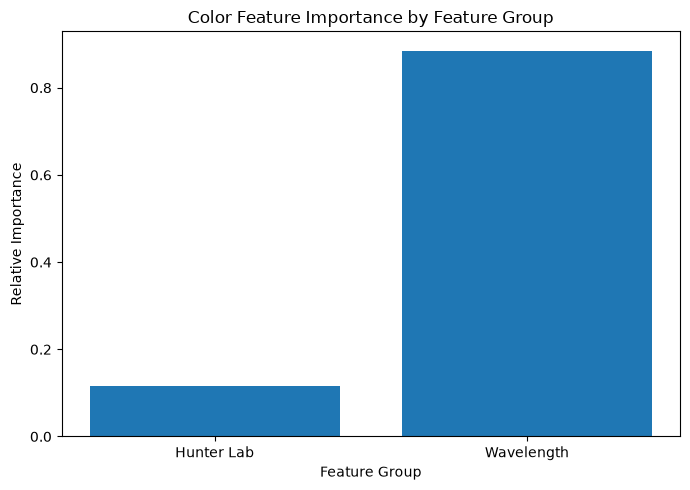

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    color_group_importance["Feature_Type"],
    color_group_importance["Relative_Importance"]
)

plt.xlabel("Feature Group")
plt.ylabel("Relative Importance")
plt.title("Color Feature Importance by Feature Group")

plt.tight_layout()
plt.show()

In [ ]:
color_importance.to_csv(
    "../results_color_feature_importance.csv",
    index=False
)

color_group_importance.to_csv(
    "../results_color_group_importance.csv",
    index=False
)

print("Color explainability results saved.")

Color explainability results saved.


In [ ]:
lab_features = ["L*", "a*", "b*"]

color_importance["Feature_Type"] = np.where(
    color_importance["Feature"].isin(lab_features),
    "Hunter Lab",
    "Wavelength"
)

color_group_importance = (
    color_importance
    .groupby("Feature_Type")["Importance"]
    .agg(
        Total_Importance="sum",
        Mean_Importance="mean",
        Maximum_Importance="max",
        Number_of_Features="count"
    )
    .reset_index()
)

color_group_importance["Relative_Importance"] = (
    color_group_importance["Total_Importance"]
    / color_group_importance["Total_Importance"].sum()
)

color_group_importance

,Feature_Type,Total_Importance,Mean_Importance,Maximum_Importance,Number_of_Features,Relative_Importance
0,Hunter Lab,0.114843,0.038281,0.058449,3,0.114843
1,Wavelength,0.885157,0.020585,0.064205,43,0.885157


In [ ]:
color_importance.to_csv(
    "../results_color_feature_importance.csv",
    index=False
)

color_group_importance.to_csv(
    "../results_color_group_importance.csv",
    index=False
)

EfficientNet-B0 Explainability

In [ ]:
image_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

image_rf.fit(
    X_image_train_scaled,
    y_train
)

y_image_rf_pred = image_rf.predict(
    X_image_test_scaled
)

print(
    "Image Random Forest Accuracy:",
    accuracy_score(y_test, y_image_rf_pred)
)

print(
    "Image Random Forest Macro F1:",
    f1_score(
        y_test,
        y_image_rf_pred,
        average="macro"
    )
)

Image Random Forest Accuracy: 0.9428571428571428
Image Random Forest Macro F1: 0.9420336555674903


In [ ]:
image_feature_names = [
    f"Feature_{i}"
    for i in range(X_image_train_scaled.shape[1])
]

image_importance = pd.DataFrame({
    "Feature": image_feature_names,
    "Importance": image_rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

image_importance.head(20)

,Feature,Importance
484,Feature_484,0.008937
430,Feature_430,0.008923
1171,Feature_1171,0.008611
1187,Feature_1187,0.008595
338,Feature_338,0.008262
488,Feature_488,0.007581
126,Feature_126,0.007564
1271,Feature_1271,0.007493
947,Feature_947,0.007462
166,Feature_166,0.007237


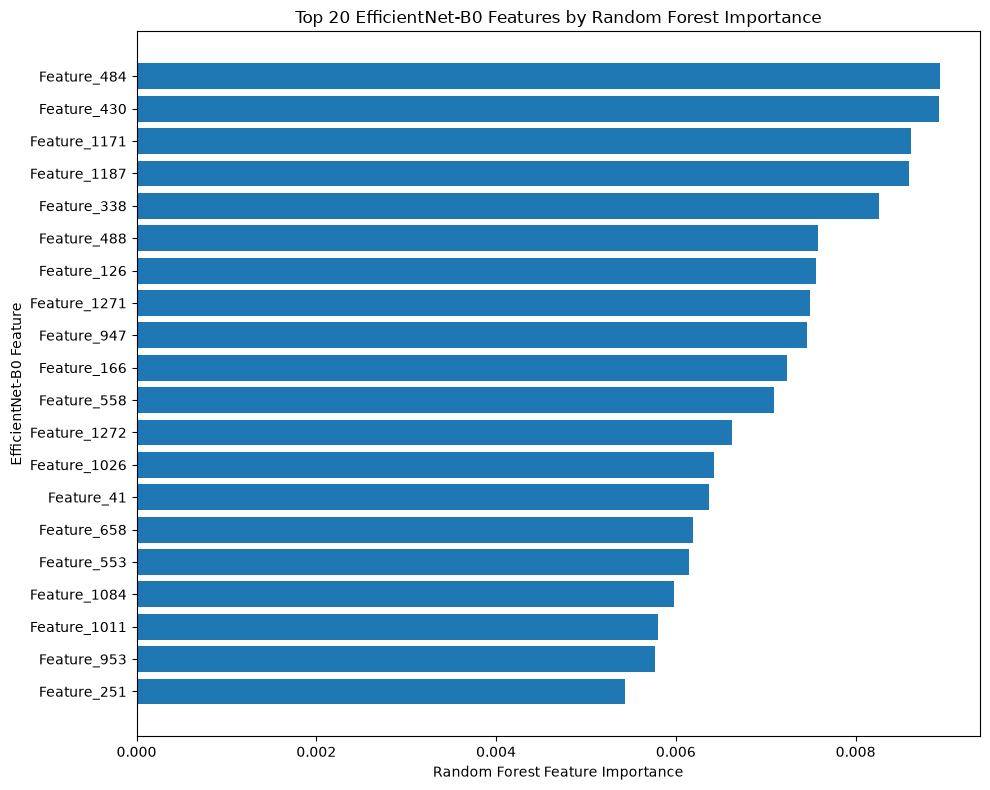

In [ ]:
top_image = (
    image_importance
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_image["Feature"],
    top_image["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("EfficientNet-B0 Feature")
plt.title("Top 20 EfficientNet-B0 Features by Random Forest Importance")

plt.tight_layout()
plt.show()

## 12. Explainability Comparison Across Modalities

The explainability analysis was performed independently for the three
modalities.

For FTIR, Random Forest impurity importance was examined at individual
wavenumbers and across broad spectral regions. Permutation importance was
also evaluated.

For Color, Random Forest feature importance was examined across Hunter Lab
features and wavelength measurements.

For Image, Random Forest importance was examined across the 1280-dimensional
EfficientNet-B0 embedding.

The results should be interpreted as model-specific statistical importance,
not as evidence of direct chemical or physical causation.

In [ ]:
explainability_summary = pd.DataFrame({
    "Modality": [
        "FTIR",
        "Color",
        "Image"
    ],
    "Model": [
        "Random Forest",
        "Random Forest",
        "Random Forest"
    ],
    "Test_Accuracy": [
        accuracy_score(y_test, y_ftir_rf_pred),
        accuracy_score(y_test, y_color_rf_pred),
        accuracy_score(y_test, y_image_rf_pred)
    ],
    "Macro_F1": [
        f1_score(y_test, y_ftir_rf_pred, average="macro"),
        f1_score(y_test, y_color_rf_pred, average="macro"),
        f1_score(y_test, y_image_rf_pred, average="macro")
    ]
})

explainability_summary

,Modality,Model,Test_Accuracy,Macro_F1
0,FTIR,Random Forest,1.000000,1.000000
1,Color,Random Forest,0.914286,0.914142
2,Image,Random Forest,0.942857,0.942034


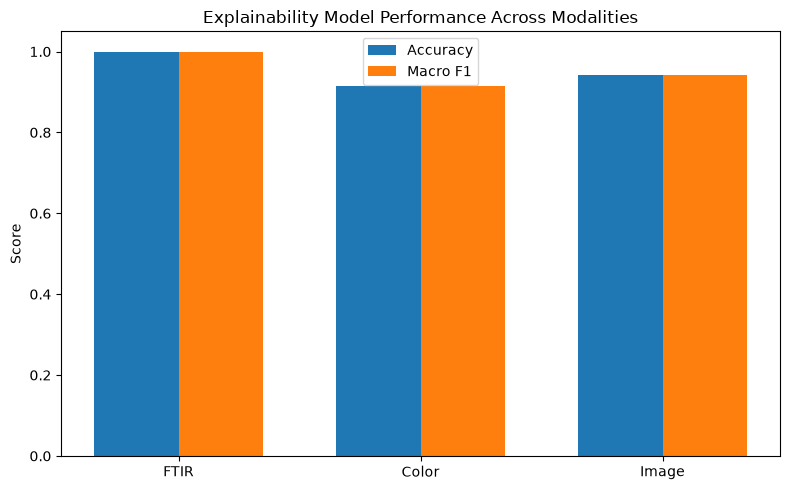

In [ ]:
plt.figure(figsize=(8, 5))

x = np.arange(len(explainability_summary))
width = 0.35

plt.bar(
    x - width/2,
    explainability_summary["Test_Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    explainability_summary["Macro_F1"],
    width,
    label="Macro F1"
)

plt.xticks(
    x,
    explainability_summary["Modality"]
)

plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.title("Explainability Model Performance Across Modalities")

plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The explainability experiments show that all three modalities contain
predictive information for the evaluated adulteration classification task.

The Random Forest models achieved strong performance on the fixed test set,
while the feature-importance analyses revealed different patterns of
information distribution.

FTIR showed importance concentrated across multiple spectral regions,
while permutation importance of individual wavelengths was negligible.
This indicates that predictive information may be distributed across
correlated spectral measurements.

Color importance was dominated by wavelength measurements rather than the
three Hunter Lab variables. Several neighboring wavelengths around
approximately 490–530 nm received relatively high importance.

The EfficientNet-B0 image representation also showed distributed importance
across multiple learned embedding dimensions.

These results demonstrate that the modalities encode information in
different forms. However, feature importance is model-dependent and should
not be interpreted as direct chemical causation.

-------------------------------------------------------------------------------------------------

## 13. Final Interpretation

The explainability analysis provides insight into how the three modalities
contribute to the machine-learning predictions.

### FTIR Spectroscopy

The FTIR Random Forest showed that model importance was distributed across
multiple spectral regions rather than being concentrated at a single
wavenumber.

The impurity-based feature importance highlighted several regions,
particularly within approximately 399–800 cm⁻¹ and 2800–4000 cm⁻¹.

However, permutation importance of individual FTIR features produced
negligible changes in macro F1 on the evaluated test set.

This suggests that predictive information may be distributed across
correlated or redundant spectral measurements. Therefore, individual
wavenumber importance should not be interpreted as evidence that a specific
wavenumber alone determines adulteration.

### Color Measurements

The Color Random Forest achieved 91.43% accuracy and a macro F1-score of
91.41% on the fixed test set.

The feature-group analysis showed that wavelength measurements accounted for
approximately 88.52% of total Random Forest feature importance, while the
three Hunter Lab variables accounted for approximately 11.48%.

Several neighboring wavelengths around approximately 490–530 nm appeared
among the most important individual features.

The concentration of importance across neighboring wavelengths is
consistent with the broader color patterns observed during exploratory
data analysis.

### Image Features

The EfficientNet-B0 image representation also contained predictive
information.

The Image Random Forest achieved 94.29% accuracy and a macro F1-score of
94.20% on the fixed test set.

Importance was distributed across multiple learned EfficientNet-B0
embedding dimensions rather than being dominated by one feature.

Because these features are learned representations, individual dimensions
such as Feature_484 or Feature_430 cannot be assigned direct physical
meanings without additional investigation.

### Overall Explainability Finding

The three modalities encode adulteration-related information in different
forms:

- FTIR provides high-dimensional spectral information.
- Color measurements provide wavelength and colorimetric information.
- EfficientNet-B0 provides learned image representations.

The explainability results support the presence of predictive information
across all three modalities.

However, feature importance is model-dependent and statistical in nature.
It does not establish chemical causation, identify a unique adulteration
mechanism, or prove that an individual feature is independently responsible
for the observed predictions.

The results should therefore be interpreted as evidence about model
behavior rather than as a definitive chemical explanation.

# 14. Conclusion

This notebook investigated the features contributing to turmeric
adulteration classification across FTIR spectroscopy, color measurements,
and EfficientNet-B0 image representations.

The explainability analysis produced several important observations.

1. **FTIR Spectroscopy**

   Random Forest feature importance showed concentration across multiple
   spectral regions. Permutation importance of individual features was
   negligible on the evaluated test set, suggesting that predictive
   information may be distributed across correlated spectral measurements.

2. **Color Measurements**

   Wavelength measurements represented approximately 88.52% of total
   Random Forest feature importance, compared with approximately 11.48%
   for the Hunter Lab variables. Important wavelength features were
   concentrated around several neighboring regions, particularly around
   490–530 nm.

3. **Image Representation**

   EfficientNet-B0 features provided a strong learned representation for
   the classification task. Random Forest importance was distributed across
   multiple embedding dimensions rather than being concentrated in a single
   feature.

4. **Cross-Modality Observation**

   Each modality provides a different representation of the turmeric
   samples. FTIR captures spectral information, color measurements capture
   wavelength and colorimetric information, and EfficientNet-B0 captures
   learned visual representations.

5. **Scientific Interpretation**

   Feature importance and permutation importance describe statistical
   relationships between model inputs and predictions. They do not by
   themselves establish chemical causation or guarantee that the identified
   features will remain important on independently collected samples.

6. **Research Significance**

   The explainability analysis improves the interpretability of the
   FoodSure AI prototype by identifying which types of measurements and
   feature regions contribute to model behavior.

The findings provide a basis for the subsequent robustness analysis, where
model stability will be evaluated across multiple train-validation splits.

### Final Note

FoodSure AI is an AI-assisted research prototype for turmeric adulteration
screening and estimation. The current results are based on a controlled
dataset containing turmeric samples adulterated with wheat flour.

Independent validation using unseen physical samples and laboratory
verification would be required before making claims about broader
real-world performance.